In [1]:
import pandas as pd
import numpy as np

# 1. Read the output file
# 'skiprows=9' skips the LAMMPS header to reach the atom data
df = pd.read_csv("output.txt", skiprows=9, sep='\s+', 
                 names=['id', 'type', 'x', 'y', 'z', 'fx', 'fy', 'fz'])

# 2. Calculate acceleration (F = m.a -> a = F/m)
# In 'metal' units: Force = eV/Angstrom, Mass = g/mol
# Atomic masses: Al = 26.98, Ti = 47.86
df['ax'] = np.where(df['type'] == 1, df['fx']/26.98, df['fx']/47.86)
df['ay'] = np.where(df['type'] == 1, df['fy']/26.98, df['fy']/47.86)
df['az'] = np.where(df['type'] == 1, df['fz']/26.98, df['fz']/47.86)

# 3. Create matrices (NumPy arrays) for further analysis
position_matrix = df[['x', 'y', 'z']].values
acceleration_matrix = df[['ax', 'ay', 'az']].values

print("Simulation Data Successfully Retrieved!")
print("-" * 30)
print(f"First 5 atoms - Position values:\n{position_matrix[:5]}")
print(f"First 5 atoms - Acceleration values:\n{acceleration_matrix[:5]}")
print("-" * 30)

Simulation Data Successfully Retrieved!
------------------------------
First 5 atoms - Position values:
[[0.    0.    0.   ]
 [2.025 2.025 0.   ]
 [2.025 0.    2.025]
 [0.    2.025 2.025]
 [4.05  0.    0.   ]]
First 5 atoms - Acceleration values:
[[-0.00219766  0.00059033 -0.00039789]
 [-0.00468484 -0.00142876  0.00444855]
 [-0.0023286  -0.00114793 -0.00139445]
 [ 0.00284902 -0.00144748  0.00011059]
 [-0.00249599 -0.00036669  0.00163101]]
------------------------------


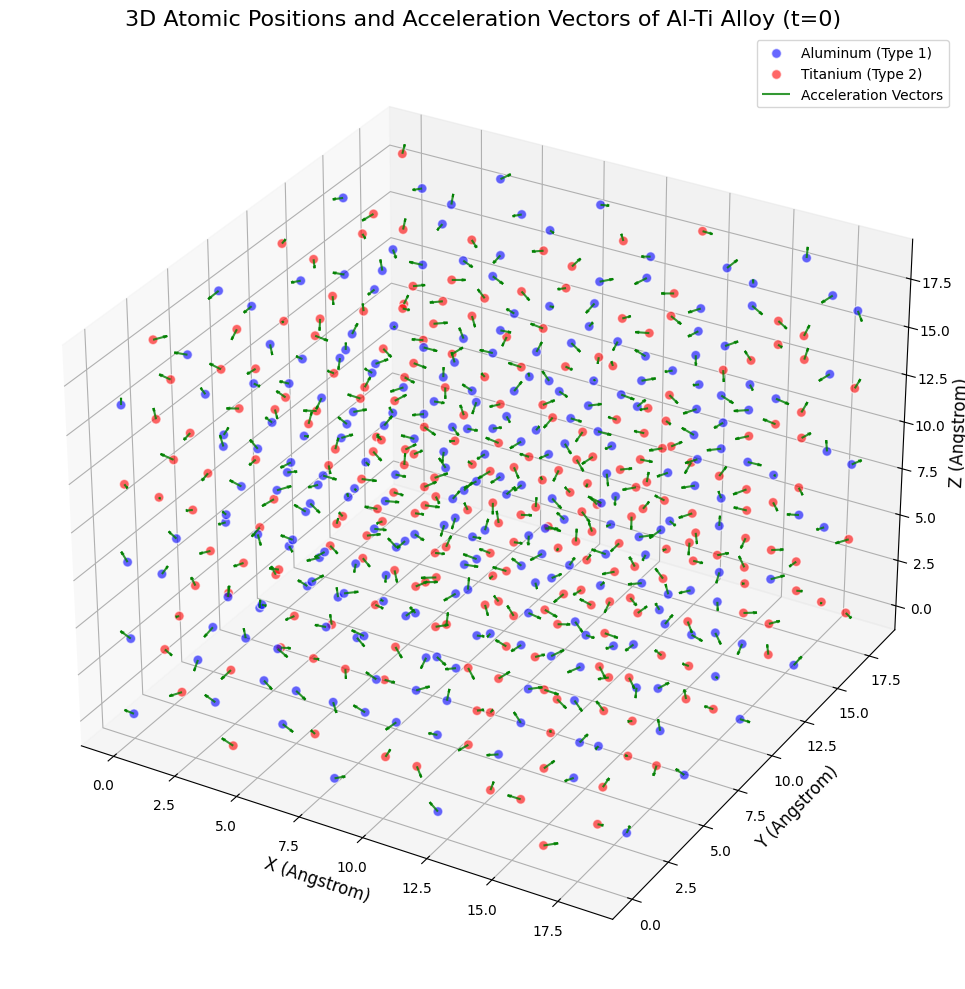

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# 1. Read the output file
# Ensure output.txt is in the same directory as your notebook
df = pd.read_csv("output.txt", skiprows=9, sep='\s+', 
                 names=['id', 'type', 'x', 'y', 'z', 'fx', 'fy', 'fz'])

# 2. Calculate Accelerations (a = F/m)
# Atomic masses for metal units: Al ~ 26.98, Ti ~ 47.86
df['ax'] = np.where(df['type'] == 1, df['fx']/26.98, df['fx']/47.86)
df['ay'] = np.where(df['type'] == 1, df['fy']/26.98, df['fy']/47.86)
df['az'] = np.where(df['type'] == 1, df['fz']/26.98, df['fz']/47.86)

# 3. Visualization Setup
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Filter atoms by type for color coding
al_atoms = df[df['type'] == 1]
ti_atoms = df[df['type'] == 2]

# Plot Aluminum Atoms (Blue)
ax.scatter(al_atoms['x'], al_atoms['y'], al_atoms['z'], 
           c='blue', label='Aluminum (Type 1)', s=50, alpha=0.6, edgecolors='w')

# Plot Titanium Atoms (Red)
ax.scatter(ti_atoms['x'], ti_atoms['y'], ti_atoms['z'], 
           c='red', label='Titanium (Type 2)', s=50, alpha=0.6, edgecolors='w')

# 4. Add Acceleration Vectors (Quiver Plot)
# Normalizing and scaling the vectors for better visibility
norm_accel = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
max_norm = np.max(norm_accel) if np.max(norm_accel) > 0 else 1
scale_factor = 2.0 / max_norm 

ax.quiver(df['x'], df['y'], df['z'], 
          df['ax']*scale_factor, df['ay']*scale_factor, df['az']*scale_factor,
          length=0.5, normalize=True, color='green', alpha=0.8, label='Acceleration Vectors')

# 5. Plot Details and Labels
ax.set_title("3D Atomic Positions and Acceleration Vectors of Al-Ti Alloy (t=0)", fontsize=16)
ax.set_xlabel("X (Angstrom)", fontsize=12)
ax.set_ylabel("Y (Angstrom)", fontsize=12)
ax.set_zlabel("Z (Angstrom)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()